# SECOM EDA — 1주차

목표
1. SECOM 데이터 로드
2. 결측값 패턴 시각화 및 결측률 50% 초과 피처 목록화
3. 클래스 분포(정상/불량) 확인
4. 저분산 피처 확인

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

DATA_DIR = "../data/raw"
pd.set_option("display.max_columns", 50)

## 1. 데이터 로드

`secom.data`는 공백으로 구분된 590개 피처, `secom_labels.data`는 라벨(-1=정상, 1=불량)과 타임스탬프.

In [2]:
X = pd.read_csv(f"{DATA_DIR}/secom.data", sep=" ", header=None)
X.columns = [f"feature_{i+1}" for i in range(X.shape[1])]

labels_raw = pd.read_csv(f"{DATA_DIR}/secom_labels.data", sep=" ", header=None, names=["label", "timestamp"])

df = X.copy()
df["label"] = labels_raw["label"]
df["timestamp"] = pd.to_datetime(labels_raw["timestamp"])

print(df.shape)
df.head()

(1567, 592)


C:\Users\MYCOM\AppData\Local\Temp\ipykernel_3384\3244652168.py:8: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["timestamp"] = pd.to_datetime(labels_raw["timestamp"])


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,...,feature_568,feature_569,feature_570,feature_571,feature_572,feature_573,feature_574,feature_575,feature_576,feature_577,feature_578,feature_579,feature_580,feature_581,feature_582,feature_583,feature_584,feature_585,feature_586,feature_587,feature_588,feature_589,feature_590,label,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,...,NaN,NaN,NaN,533.8500,2.1113,8.95,0.3157,3.0624,0.1026,1.6765,14.9509,NaN,NaN,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,2008-07-19 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,-0.0148,0.9627,200.5470,0.0,10.1548,414.7347,9.2599,0.9701,191.2872,12.4608,1.3825,-5441.50,2604.25,-3498.75,-1640.25,...,NaN,NaN,NaN,535.0164,2.4335,5.92,0.2653,2.0111,0.0772,1.1065,10.9003,0.0096,0.0201,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,2008-07-19 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,0.0013,0.9615,202.0179,0.0,9.5157,416.7075,9.3144,0.9674,192.7035,12.5404,1.4123,-5447.75,2701.75,-4047.00,-1916.50,...,0.2562,0.4119,68.8489,535.0245,2.0293,11.21,0.1882,4.0923,0.0640,2.0952,9.2721,0.0584,0.0484,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,2008-07-19 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,-0.0033,0.9629,201.8482,0.0,9.6052,422.2894,9.6924,0.9687,192.1557,12.4782,1.4011,-5468.25,2648.25,-4515.00,-1657.25,...,0.0670,2.7290,25.0363,530.5682,2.0253,9.33,0.1738,2.8971,0.0525,1.7585,8.5831,0.0202,0.0149,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,-0.0072,0.9569,201.9424,0.0,10.5661,420.5925,10.3387,0.9735,191.6037,12.4735,1.3888,-5476.25,2635.25,-3987.50,117.00,...,NaN,NaN,NaN,532.0155,2.0275,8.83,0.2224,3.1776,0.0706,1.6597,10.9698,NaN,NaN,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 15:22:00


## 2. 결측값 패턴

In [3]:
missing_ratio = X.isna().mean().sort_values(ascending=False)
missing_ratio.head(20)

feature_293    0.911934
feature_294    0.911934
feature_159    0.911934
feature_158    0.911934
feature_493    0.855775
feature_86     0.855775
feature_359    0.855775
feature_221    0.855775
feature_245    0.649649
feature_518    0.649649
feature_110    0.649649
feature_247    0.649649
feature_384    0.649649
feature_383    0.649649
feature_385    0.649649
feature_246    0.649649
feature_112    0.649649
feature_111    0.649649
feature_517    0.649649
feature_519    0.649649
dtype: float64

C:\github\semiconductor-fault-detection\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\github\semiconductor-fault-detection\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\github\semiconductor-fault-detection\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\github\semiconductor-fault-detection\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\github\semiconductor-fault-detection\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

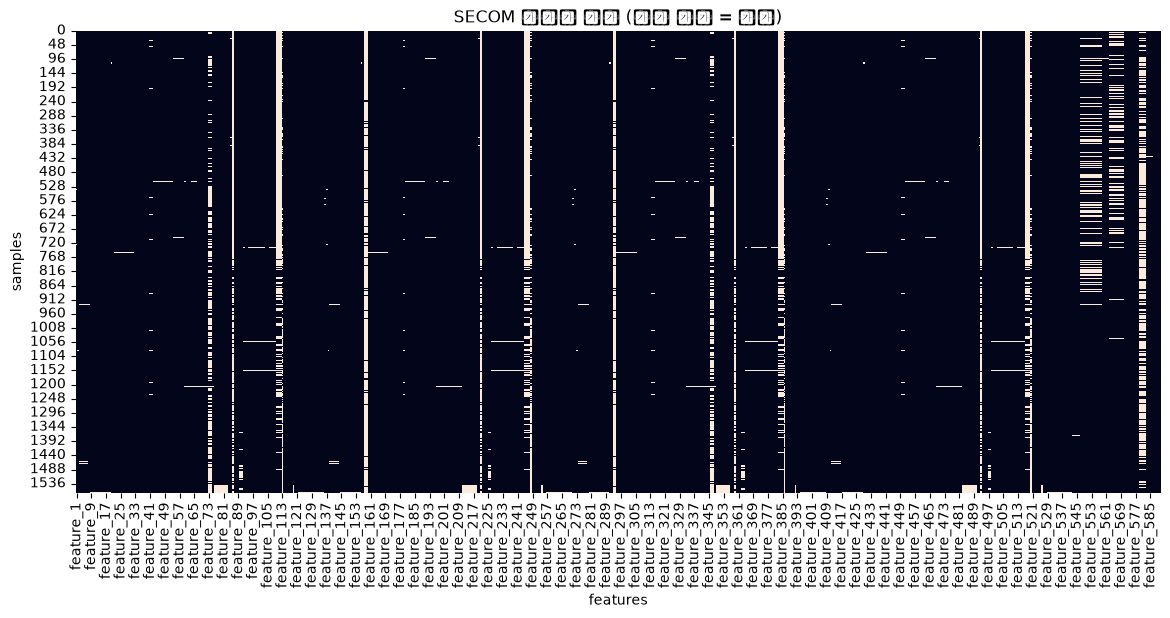

In [4]:
plt.figure(figsize=(14, 6))
sns.heatmap(X.isna(), cbar=False)
plt.title("SECOM 결측값 패턴 (밝은 부분 = 결측)")
plt.xlabel("features")
plt.ylabel("samples")
plt.show()

In [5]:
high_missing_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
print(f"결측률 50% 초과 피처 수: {len(high_missing_cols)}")
high_missing_cols

결측률 50% 초과 피처 수: 28


['feature_293',
 'feature_294',
 'feature_159',
 'feature_158',
 'feature_493',
 'feature_86',
 'feature_359',
 'feature_221',
 'feature_245',
 'feature_518',
 'feature_110',
 'feature_247',
 'feature_384',
 'feature_383',
 'feature_385',
 'feature_246',
 'feature_112',
 'feature_111',
 'feature_517',
 'feature_519',
 'feature_581',
 'feature_579',
 'feature_580',
 'feature_582',
 'feature_74',
 'feature_346',
 'feature_73',
 'feature_347']

In [6]:
X_dropped = X.drop(columns=high_missing_cols)
print(f"제거 전: {X.shape[1]}개 -> 제거 후: {X_dropped.shape[1]}개")

제거 전: 590개 -> 제거 후: 562개


## 3. 클래스 분포 (정상 / 불량)

라벨 기준: -1 = 정상(Pass), 1 = 불량(Fail)

label
-1    1463
 1     104
Name: count, dtype: int64
label
-1    93.36
 1     6.64
Name: proportion, dtype: float64


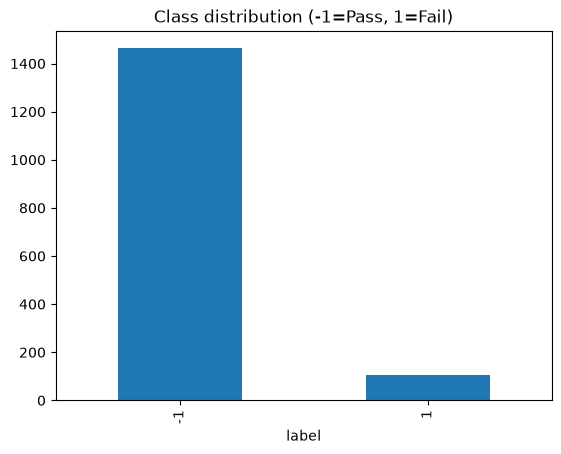

In [7]:
label_counts = df["label"].value_counts()
label_ratio = df["label"].value_counts(normalize=True) * 100
print(label_counts)
print(label_ratio.round(2))

label_counts.plot(kind="bar", title="Class distribution (-1=Pass, 1=Fail)")
plt.show()

## 4. 저분산 피처 확인

In [8]:
variances = X_dropped.var(numeric_only=True).sort_values()
low_var_cols = variances[variances == 0].index.tolist()
print(f"분산 0인 피처 수: {len(low_var_cols)}")
variances.head(20)

분산 0인 피처 수: 116


feature_451    0.0
feature_452    0.0
feature_450    0.0
feature_415    0.0
feature_405    0.0
feature_404    0.0
feature_403    0.0
feature_6      0.0
feature_382    0.0
feature_423    0.0
feature_398    0.0
feature_399    0.0
feature_400    0.0
feature_401    0.0
feature_402    0.0
feature_395    0.0
feature_43     0.0
feature_396    0.0
feature_397    0.0
feature_373    0.0
dtype: float64

## 다음 단계

- 남은 결측값은 중앙값(median)으로 대체
- 분산 0 피처 제거 후 `StandardScaler` 정규화
- SMOTE 또는 `class_weight='balanced'`로 클래스 불균형 처리
- 전처리 결과를 `data/processed/`에 저장 (`02_preprocessing.ipynb`에서 진행)